# 1. Análisis Exploratorio de Datos — Customer Churn Prediction

Problema de clasificación binaria: predecir si un cliente va a abandonar el servicio (`Churn = Yes`).

En este notebook se realiza toda la exploración tabular y visual del dataset de entrenamiento para
identificar las relaciones entre variables y el target, y generar recomendaciones para el modelado.

**Dataset:** Playground Series S6E3 — versión sintética del Telco Customer Churn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 10

print("Librerias cargadas")
print("Configuracion de visualizacion lista")

Librerias cargadas
Configuracion de visualizacion lista


## 1. Carga de Datos

In [2]:
train = pd.read_csv("../data/train.csv")
test  = pd.read_csv("../data/test.csv")

# Codificar target binario
train["target"] = (train["Churn"] == "Yes").astype(int)

# Clasificacion de features
continuous_features = ["tenure", "MonthlyCharges", "TotalCharges"]

categorical_features = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod"
]

print(f"{'='*80}")
print("DATASET CARGADO")
print(f"{'='*80}")
print(f"Train: {train.shape[0]:,} filas x {train.shape[1]} columnas")
print(f"Test:  {test.shape[0]:,} filas x {test.shape[1]} columnas")
print(f"Variables continuas:   {len(continuous_features)}")
print(f"Variables categoricas: {len(categorical_features)}")
print(f"Target: Churn (Yes / No)")
print(f"Memoria train: {train.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"{'='*80}")

DATASET CARGADO
Train: 594,194 filas x 22 columnas
Test:  254,655 filas x 20 columnas
Variables continuas:   3
Variables categoricas: 16
Target: Churn (Yes / No)
Memoria train: 525.39 MB


In [3]:
train.head(3)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,target
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,No,0
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,Yes,Yes,No,Two year,No,Credit card (automatic),69.5,3778.20,No,0
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.4,5841.35,No,0


## 2. Visión General del Dataset

In [4]:
train.info()
print("")
train[continuous_features].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000
mean,36.577258,65.866223,2494.377057
std,25.061922,31.067444,2353.916710
min,1.000000,18.250000,18.800000
25%,12.000000,29.900000,639.650000
50%,35.000000,74.100000,1433.650000
75%,62.000000,90.800000,4263.800000
max,72.000000,118.750000,8684.800000


In [5]:
print("Valores nulos por columna:")
print(train.isnull().sum())
print(f"\nFilas duplicadas (excluyendo id): {train.drop(columns='id').duplicated().sum():,}")

# Inspeccion especial de TotalCharges (puede tener espacios en blanco)
print(f"\nTotalCharges dtype: {train['TotalCharges'].dtype}")
mask_bad = pd.to_numeric(train["TotalCharges"], errors="coerce").isna()
print(f"Filas con TotalCharges no numerico: {mask_bad.sum()}")

if mask_bad.sum() > 0:
    print(train[mask_bad][["id", "tenure", "MonthlyCharges", "TotalCharges"]].head())
    train["TotalCharges"] = pd.to_numeric(train["TotalCharges"], errors="coerce")
    train["TotalCharges"].fillna(0, inplace=True)
    print("-> TotalCharges convertido y nulos imputados con 0")

Valores nulos por columna:
id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
target              0
dtype: int64

Filas duplicadas (excluyendo id): 0

TotalCharges dtype: float64
Filas con TotalCharges no numerico: 0


## 3. Distribución del Target

DISTRIBUCION DEL TARGET
  No   :    460,377  (77.48%)
  Yes  :    133,817  (22.52%)

Tasa de churn global: 22.52%


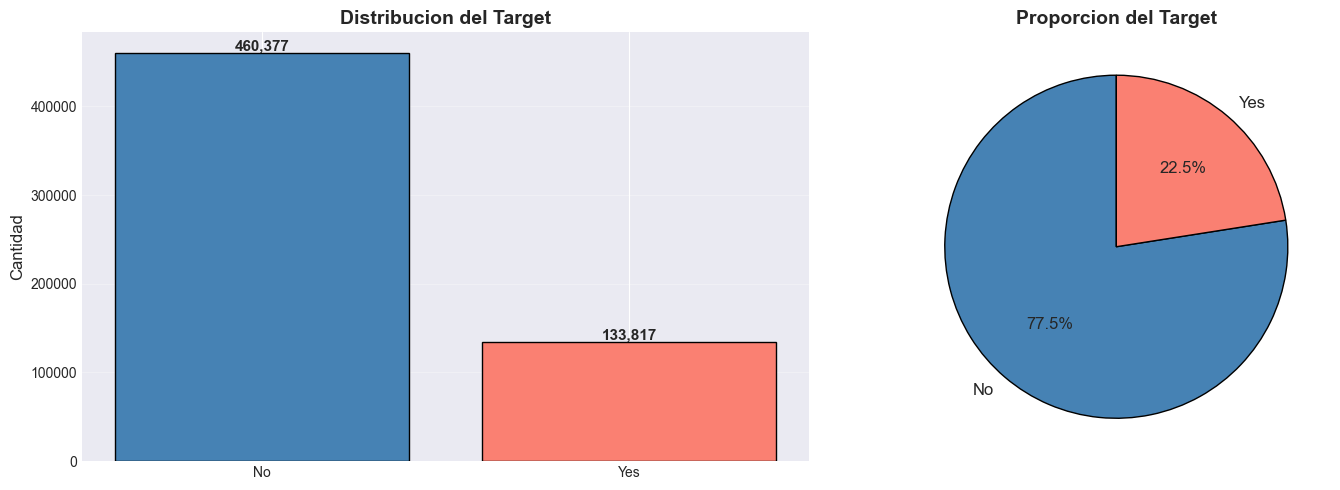

In [6]:
counts = train["Churn"].value_counts()
props  = train["Churn"].value_counts(normalize=True)
churn_rate = train["target"].mean()

print(f"{'='*80}")
print("DISTRIBUCION DEL TARGET")
print(f"{'='*80}")
for label in counts.index:
    print(f"  {label:5s}: {counts[label]:>10,}  ({props[label]:.2%})")
print(f"\nTasa de churn global: {churn_rate:.2%}")
print(f"{'='*80}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors = ["steelblue", "salmon"]

# Bar plot
axes[0].bar(counts.index, counts.values, color=colors, edgecolor="black")
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + len(train)*0.005, f"{val:,}", ha="center", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Cantidad", fontsize=12)
axes[0].set_title("Distribucion del Target", fontsize=14, fontweight="bold")
axes[0].grid(True, alpha=0.3, axis="y")

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=colors, startangle=90, textprops={"fontsize": 12},
            wedgeprops={"edgecolor": "black", "linewidth": 1})
axes[1].set_title("Proporcion del Target", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

## 4. Variables Continuas vs Target

**tenure**, **MonthlyCharges**, **TotalCharges**

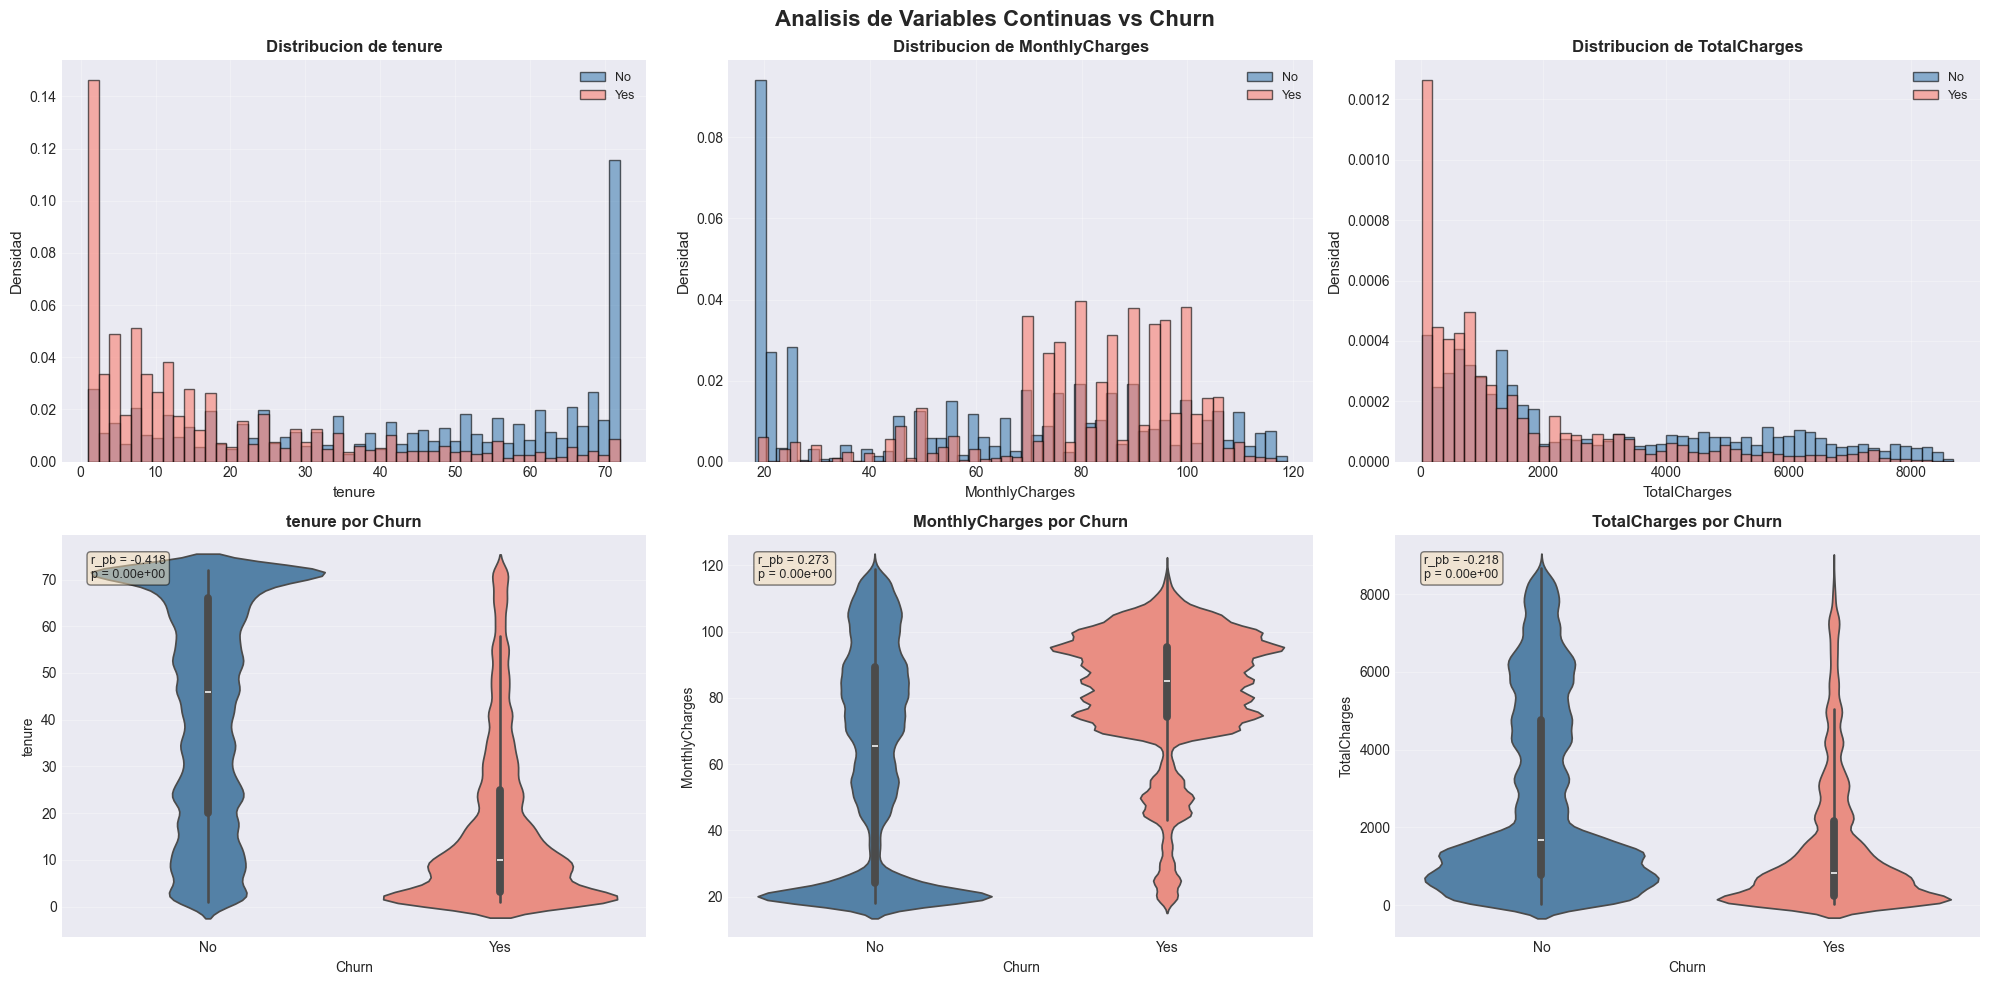

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle("Analisis de Variables Continuas vs Churn", fontsize=16, fontweight="bold")

pb_results = {}

for idx, var in enumerate(continuous_features):
    # Fila 1: Histogramas superpuestos por clase
    ax1 = axes[0, idx]
    for label, color in zip(["No", "Yes"], ["steelblue", "salmon"]):
        subset = train[train["Churn"] == label][var]
        ax1.hist(subset, bins=50, alpha=0.6, color=color, edgecolor="black",
                 label=label, density=True)
    ax1.set_xlabel(var, fontsize=11)
    ax1.set_ylabel("Densidad", fontsize=11)
    ax1.set_title(f"Distribucion de {var}", fontweight="bold")
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)

    # Fila 2: Violin plots
    ax2 = axes[1, idx]
    sns.violinplot(data=train, x="Churn", y=var, ax=ax2,
                   palette={"No": "steelblue", "Yes": "salmon"},
                   inner="box", order=["No", "Yes"])
    ax2.set_title(f"{var} por Churn", fontweight="bold")

    # Point-biserial correlation
    corr_val, pval = stats.pointbiserialr(train["target"], train[var])
    pb_results[var] = {"corr": corr_val, "pval": pval}
    ax2.text(0.05, 0.95, f"r_pb = {corr_val:.3f}\np = {pval:.2e}",
             transform=ax2.transAxes, fontsize=9, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
    ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

In [8]:
print(f"\n{'='*80}")
print("CORRELACIONES PUNTO-BISERIAL CON CHURN (Variables Continuas)")
print(f"{'='*80}")
pb_sorted = sorted(pb_results.items(), key=lambda x: abs(x[1]["corr"]), reverse=True)
for var, res in pb_sorted:
    bar = '\u2588' * int(abs(res['corr']) * 50)
    print(f"{var:20s}: r_pb = {res['corr']:+7.4f}  (p = {res['pval']:.2e})  {bar}")
print(f"{'='*80}")


CORRELACIONES PUNTO-BISERIAL CON CHURN (Variables Continuas)
tenure              : r_pb = -0.4185  (p = 0.00e+00)  ████████████████████
MonthlyCharges      : r_pb = +0.2730  (p = 0.00e+00)  █████████████
TotalCharges        : r_pb = -0.2184  (p = 0.00e+00)  ██████████


## 5. Matriz de Correlación — Variables Continuas

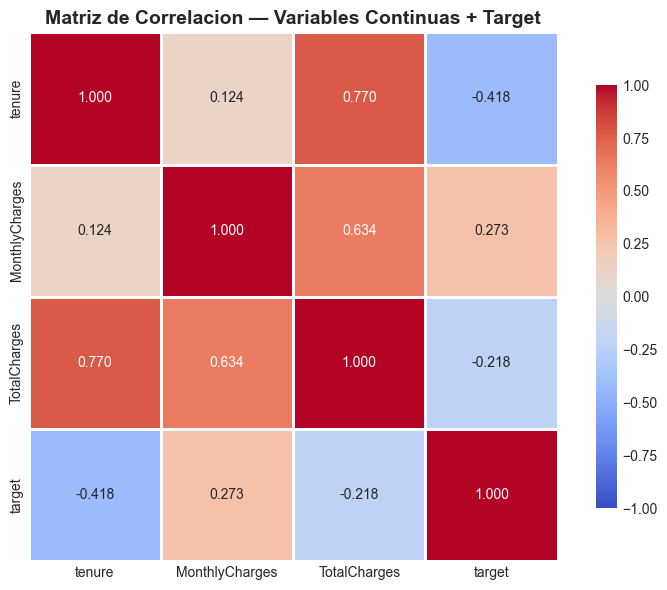

In [9]:
corr_data = train[continuous_features + ["target"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_data, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)
plt.title("Matriz de Correlacion — Variables Continuas + Target", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Variables Categóricas vs Target

**gender**, **SeniorCitizen**, **Partner**, **Dependents**, **PhoneService**,
**MultipleLines**, **InternetService**, **OnlineSecurity**, **OnlineBackup**,
**DeviceProtection**, **TechSupport**, **StreamingTV**, **StreamingMovies**,
**Contract**, **PaperlessBilling**, **PaymentMethod**

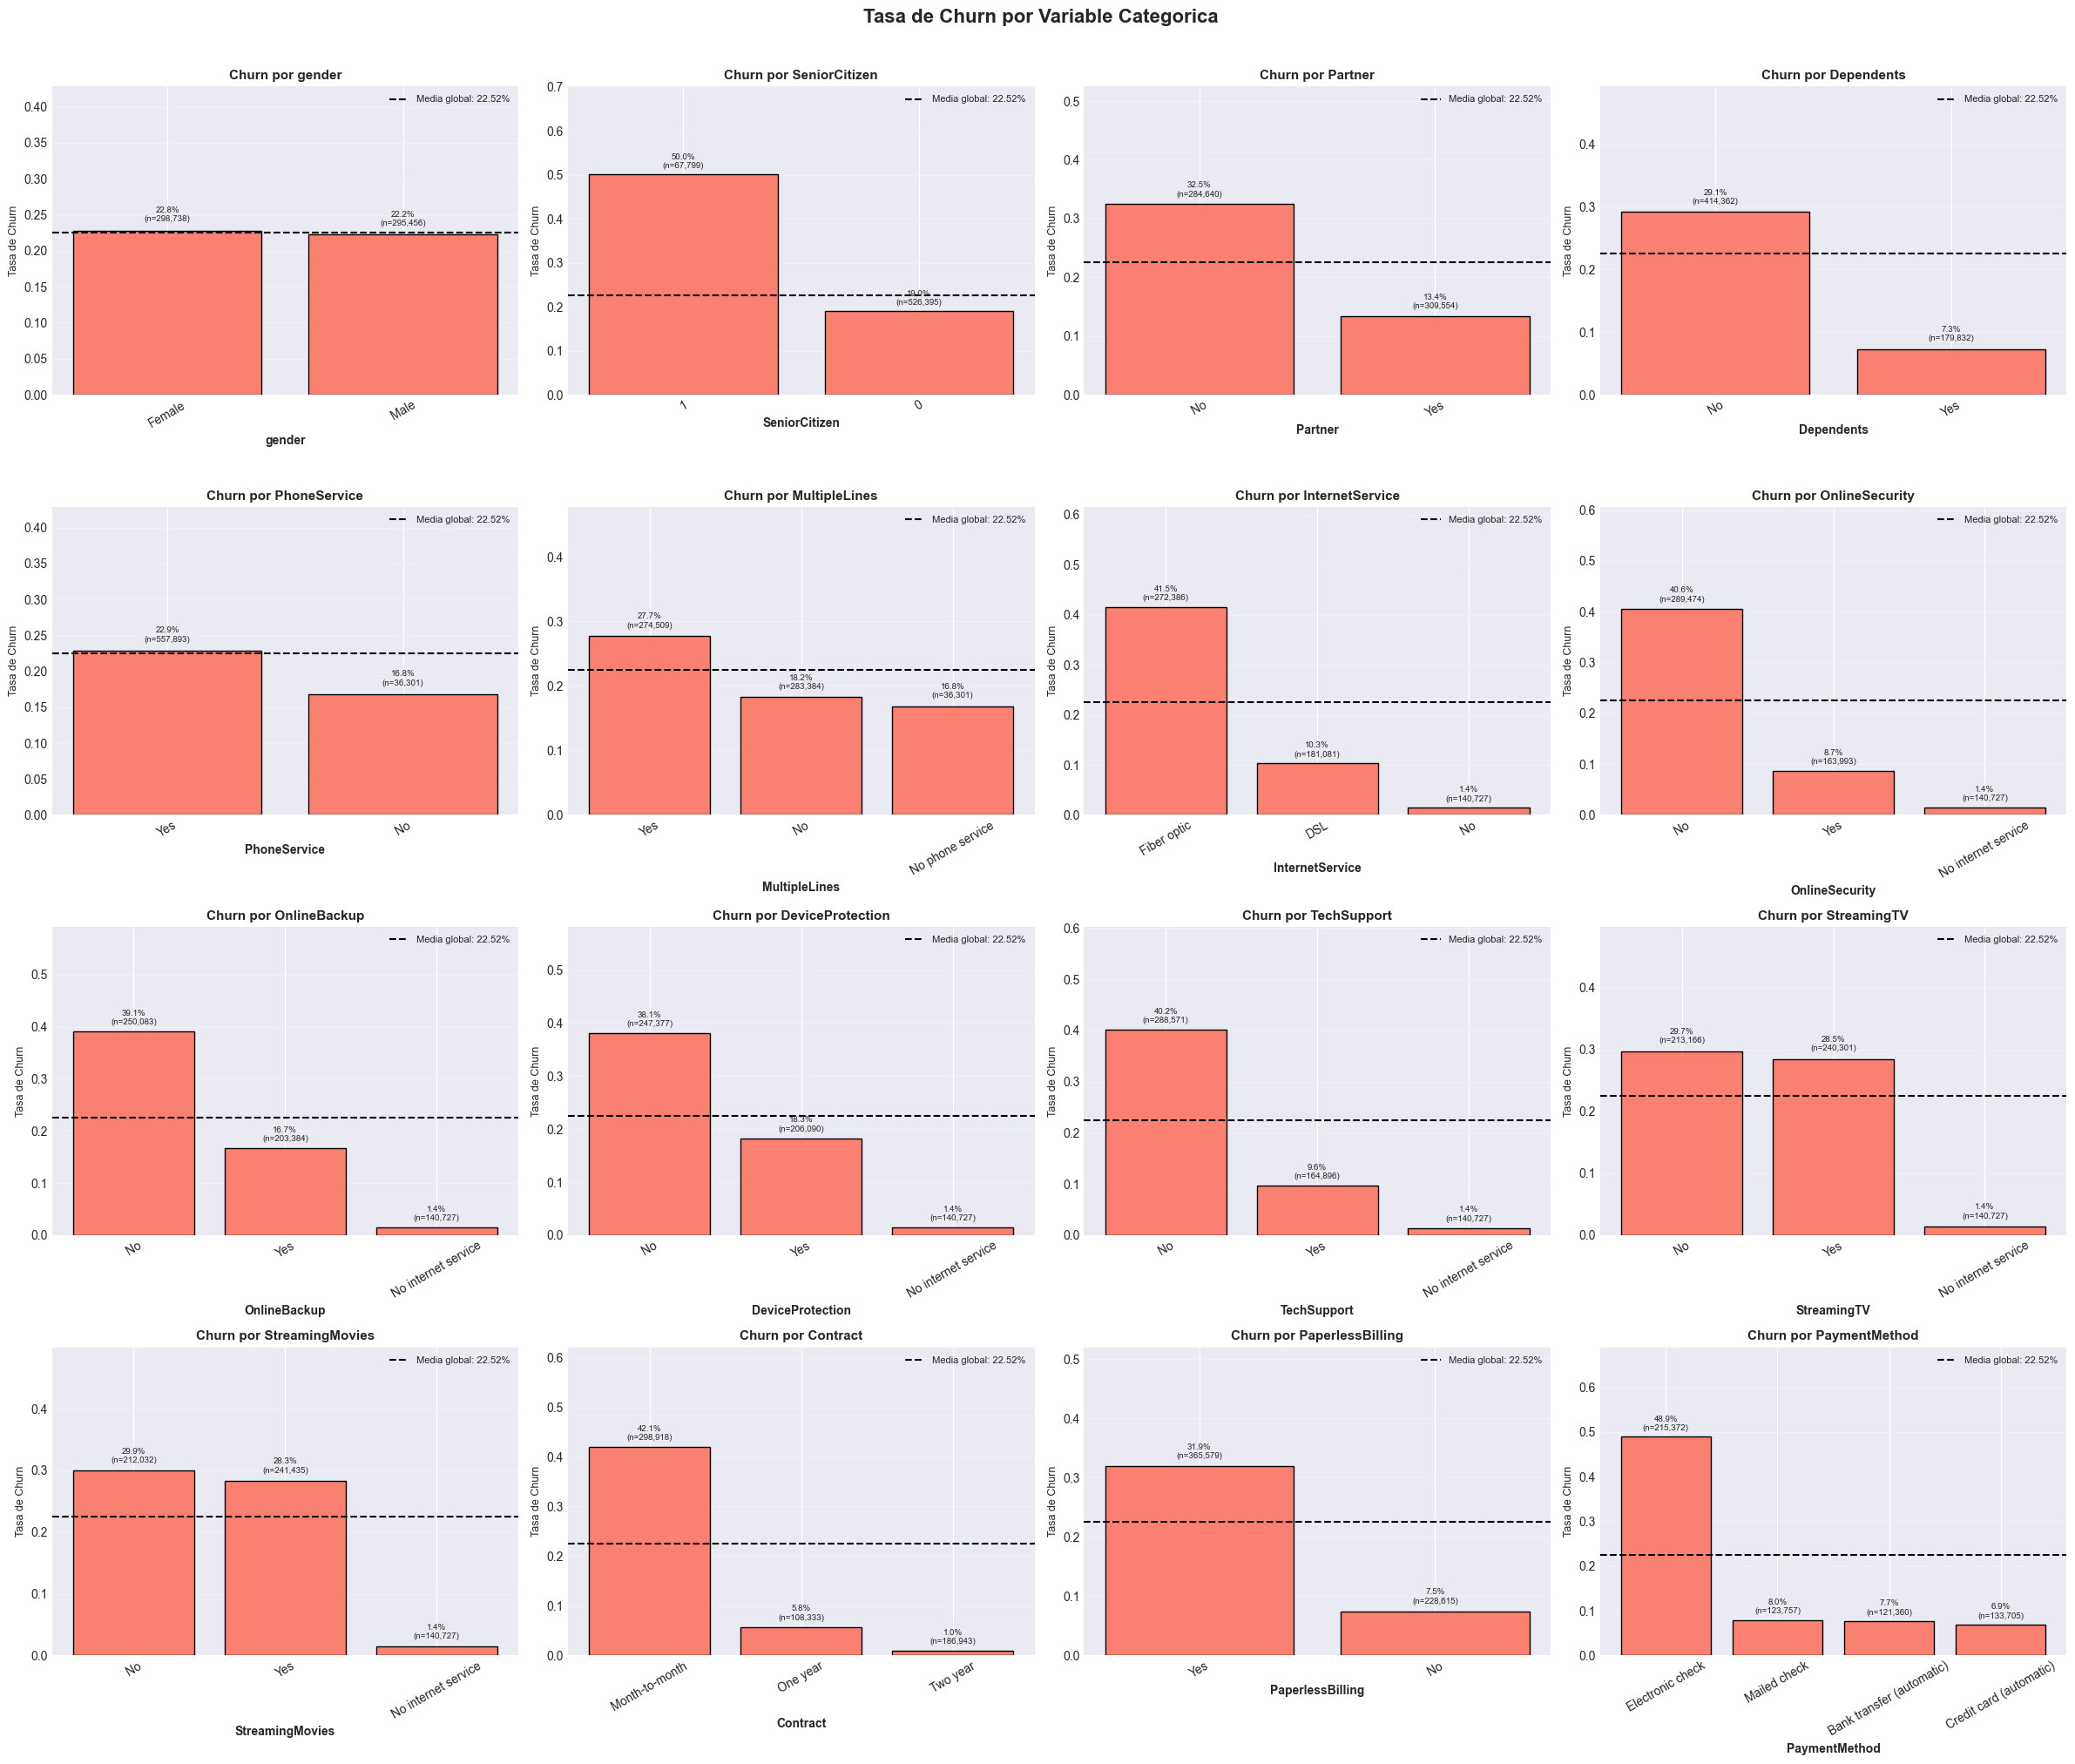

In [10]:
fig, axes = plt.subplots(4, 4, figsize=(24, 20))
axes = axes.flatten()

for idx, var in enumerate(categorical_features):
    ax = axes[idx]

    rate       = train.groupby(var)["target"].mean().sort_values(ascending=False)
    counts_cat = train[var].value_counts()

    bars = ax.bar(rate.index.astype(str), rate.values, color="salmon", edgecolor="black")
    ax.axhline(train["target"].mean(), color="black", linestyle="--", linewidth=1.5,
               label=f"Media global: {train['target'].mean():.2%}")

    for bar, cat in zip(bars, rate.index):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                f"{height:.1%}\n(n={counts_cat.get(cat, 0):,})",
                ha="center", va="bottom", fontsize=7)

    ax.set_xlabel(var, fontsize=10, fontweight="bold")
    ax.set_ylabel("Tasa de Churn", fontsize=9)
    ax.set_title(f"Churn por {var}", fontsize=11, fontweight="bold")
    ax.set_ylim(0, min(rate.max() + 0.20, 1.0))
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Tasa de Churn por Variable Categorica", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [11]:
print(f"\n{'='*80}")
print("ANALISIS ESTADISTICO — VARIABLES CATEGORICAS (Chi-cuadrado + Cramer's V)")
print(f"{'='*80}")

chi2_results = {}

for var in categorical_features:
    print(f"\n{var.upper()}:")
    print("-" * 70)

    ct = pd.crosstab(train[var], train["Churn"])

    rate = train.groupby(var)["target"].agg(["count", "mean", "sum"]).sort_values("mean", ascending=False)
    rate.columns = ["n", "tasa_churn", "n_churn"]
    rate["n_no_churn"] = rate["n"] - rate["n_churn"]
    print(rate.to_string())

    chi2, pval, dof, _ = stats.chi2_contingency(ct)
    n         = ct.sum().sum()
    min_dim   = min(ct.shape[0], ct.shape[1]) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

    chi2_results[var] = {"chi2": chi2, "pval": pval, "cramers_v": cramers_v}

    sig = "MUY significativa (p < 0.001)" if pval < 0.001 else ("significativa (p < 0.05)" if pval < 0.05 else "NO significativa (p >= 0.05)")
    print(f"\nChi2 = {chi2:.2f}, p-value = {pval:.2e}, Cramer's V = {cramers_v:.4f}  ->  {sig}")

print(f"\n{'='*80}")


ANALISIS ESTADISTICO — VARIABLES CATEGORICAS (Chi-cuadrado + Cramer's V)

GENDER:
----------------------------------------------------------------------
             n  tasa_churn  n_churn  n_no_churn
gender                                         
Female  298738    0.228036    68123      230615
Male    295456    0.222348    65694      229762

Chi2 = 27.51, p-value = 1.56e-07, Cramer's V = 0.0068  ->  MUY significativa (p < 0.001)

SENIORCITIZEN:
----------------------------------------------------------------------
                    n  tasa_churn  n_churn  n_no_churn
SeniorCitizen                                         
1               67799    0.500317    33921       33878
0              526395    0.189774    99896      426499

Chi2 = 33193.98, p-value = 0.00e+00, Cramer's V = 0.2364  ->  MUY significativa (p < 0.001)

PARTNER:
----------------------------------------------------------------------
              n  tasa_churn  n_churn  n_no_churn
Partner                           

## 7. Ranking de Importancia — Combinado (Continuas + Categóricas)

In [12]:
# Continuas: |r_pb|   Categoricas: Cramer's V   (ambas en escala 0-1)
importance = {}
for var in continuous_features:
    importance[var] = abs(pb_results[var]["corr"])
for var in categorical_features:
    importance[var] = chi2_results[var]["cramers_v"]

importance_series = pd.Series(importance).sort_values(ascending=False)
importance_norm   = (importance_series / importance_series.max()) * 100

print(f"\n{'='*80}")
print("RANKING FINAL DE VARIABLES (Importancia Normalizada 0-100)")
print(f"{'='*80}")
for i, (var, score) in enumerate(importance_norm.items(), 1):
    var_type = "CON" if var in continuous_features else "CAT"
    bar = '\u2588' * int(score / 5)
    print(f"{i:2d}. {var:25s} [{var_type}]: {score:6.2f}  {bar}")
print(f"{'='*80}")


RANKING FINAL DE VARIABLES (Importancia Normalizada 0-100)
 1. PaymentMethod             [CAT]: 100.00  ████████████████████
 2. Contract                  [CAT]:  99.11  ███████████████████
 3. OnlineSecurity            [CAT]:  89.58  █████████████████
 4. InternetService           [CAT]:  89.42  █████████████████
 5. tenure                    [CON]:  87.85  █████████████████
 6. TechSupport               [CAT]:  87.41  █████████████████
 7. OnlineBackup              [CAT]:  76.64  ███████████████
 8. DeviceProtection          [CAT]:  73.21  ██████████████
 9. PaperlessBilling          [CAT]:  59.85  ███████████
10. StreamingMovies           [CAT]:  59.15  ███████████
11. StreamingTV               [CAT]:  59.11  ███████████
12. MonthlyCharges            [CON]:  57.31  ███████████
13. Dependents                [CAT]:  50.46  ██████████
14. SeniorCitizen             [CAT]:  49.62  █████████
15. Partner                   [CAT]:  47.91  █████████
16. TotalCharges              [CON]:  45.8

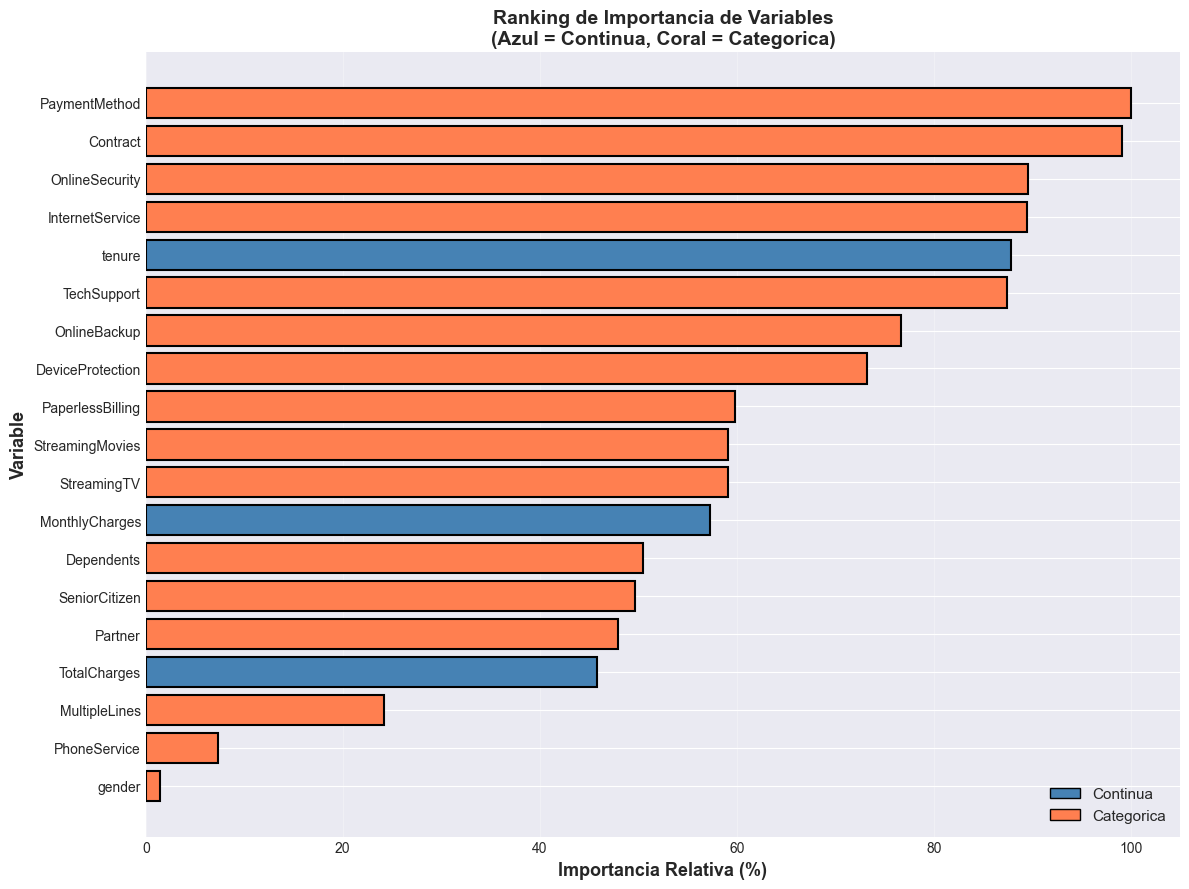

In [13]:
plt.figure(figsize=(12, 9))
colors_rank = ["steelblue" if var in continuous_features else "coral"
               for var in importance_norm.index]
plt.barh(importance_norm.index, importance_norm.values, color=colors_rank,
         edgecolor="black", linewidth=1.5)
plt.xlabel("Importancia Relativa (%)", fontsize=13, fontweight="bold")
plt.ylabel("Variable", fontsize=13, fontweight="bold")
plt.title("Ranking de Importancia de Variables\n(Azul = Continua, Coral = Categorica)",
          fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis="x")

legend_elements = [
    Patch(facecolor="steelblue", edgecolor="black", label="Continua"),
    Patch(facecolor="coral",     edgecolor="black", label="Categorica")
]
plt.legend(handles=legend_elements, loc="lower right", fontsize=11)
plt.tight_layout()
plt.show()

## 8. Pairplot — Top Variables

Top variables incluidas en pairplot:
  1. tenure

Generando pairplot con muestra de 5,000 registros...


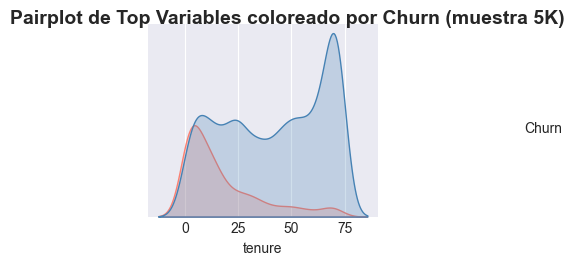

In [14]:
# Seleccion automatica: numericas + binarias codificables del top del ranking
top_vars_numeric = [v for v in importance_norm.head(8).index if v in continuous_features]
top_cats_binary  = [v for v in importance_norm.head(8).index
                    if v in categorical_features and train[v].nunique() == 2]

plot_df = train[top_vars_numeric + top_cats_binary + ["Churn"]].copy()
for col in top_cats_binary:
    uniques = sorted(plot_df[col].dropna().unique())
    plot_df[col] = plot_df[col].map({uniques[0]: 0, uniques[1]: 1})

top_plot_vars = top_vars_numeric + top_cats_binary
plot_sample   = plot_df[top_plot_vars + ["Churn"]].sample(5000, random_state=42)

print(f"Top variables incluidas en pairplot:")
for i, v in enumerate(top_plot_vars, 1):
    print(f"  {i}. {v}")
print(f"\nGenerando pairplot con muestra de {len(plot_sample):,} registros...")

sns.pairplot(plot_sample, hue="Churn", diag_kind="kde",
             palette={"No": "steelblue", "Yes": "salmon"},
             plot_kws={"alpha": 0.4, "s": 15}, corner=True)
plt.suptitle("Pairplot de Top Variables coloreado por Churn (muestra 5K)",
             y=1.02, fontsize=14, fontweight="bold")
plt.show()

## 9. Conclusiones y Recomendaciones

In [15]:
print(f"\n{'='*80}")
print("RESUMEN DE ANALISIS EXPLORATORIO — CUSTOMER CHURN")
print(f"{'='*80}")

print(f"\nDATASET:")
print(f"  - Train: {len(train):,} registros")
print(f"  - Test:  {len(test):,} registros")
print(f"  - Variables continuas:   {len(continuous_features)}")
print(f"  - Variables categoricas: {len(categorical_features)}")
print(f"  - Tasa de churn: {train['target'].mean():.2%}  (desbalance a considerar)")

print(f"\nTOP 5 VARIABLES MAS IMPORTANTES:")
for i, (var, score) in enumerate(importance_norm.head(5).items(), 1):
    var_type = "Continua" if var in continuous_features else "Categorica"
    print(f"  {i}. {var} ({var_type}): {score:.2f}%")

print(f"\nCORRELACIONES PUNTO-BISERIAL (Variables Continuas):")
for var, res in sorted(pb_results.items(), key=lambda x: abs(x[1]['corr']), reverse=True):
    print(f"  - {var}: r_pb = {res['corr']:+.4f}")

print(f"\nVARIABLES CATEGORICAS MAS SIGNIFICATIVAS (Cramer's V):")
for var in sorted(chi2_results, key=lambda x: chi2_results[x]['cramers_v'], reverse=True)[:5]:
    v = chi2_results[var]['cramers_v']
    p = chi2_results[var]['pval']
    print(f"  - {var}: Cramer's V = {v:.4f}, p = {p:.2e}")

print(f"\nRECOMENDACIONES PARA MODELADO:")
print("-" * 80)
print("1. Variables obligatorias (alta importancia):")
for var in importance_norm.head(5).index:
    print(f"   - {var}")

print(f"\n2. Variables opcionales (importancia media):")
for var in importance_norm.iloc[5:10].index:
    print(f"   - {var}")

print(f"\n3. Variables de baja prioridad:")
for var in importance_norm.tail(5).index:
    print(f"   - {var}")

print(f"\nNOTAS TECNICAS:")
print(f"  - Tasa de churn ~{train['target'].mean():.0%}: usar class_weight='balanced' o ajustar threshold")
print(f"  - TotalCharges = tenure * MonthlyCharges (alta multicolinealidad esperada)")
print(f"  - Considerar feature engineering: ratio TotalCharges/tenure, servicios activos total")
print(f"{'='*80}")


RESUMEN DE ANALISIS EXPLORATORIO — CUSTOMER CHURN

DATASET:
  - Train: 594,194 registros
  - Test:  254,655 registros
  - Variables continuas:   3
  - Variables categoricas: 16
  - Tasa de churn: 22.52%  (desbalance a considerar)

TOP 5 VARIABLES MAS IMPORTANTES:
  1. PaymentMethod (Categorica): 100.00%
  2. Contract (Categorica): 99.11%
  3. OnlineSecurity (Categorica): 89.58%
  4. InternetService (Categorica): 89.42%
  5. tenure (Continua): 87.85%

CORRELACIONES PUNTO-BISERIAL (Variables Continuas):
  - tenure: r_pb = -0.4185
  - MonthlyCharges: r_pb = +0.2730
  - TotalCharges: r_pb = -0.2184

VARIABLES CATEGORICAS MAS SIGNIFICATIVAS (Cramer's V):
  - PaymentMethod: Cramer's V = 0.4763, p = 0.00e+00
  - Contract: Cramer's V = 0.4721, p = 0.00e+00
  - OnlineSecurity: Cramer's V = 0.4267, p = 0.00e+00
  - InternetService: Cramer's V = 0.4259, p = 0.00e+00
  - TechSupport: Cramer's V = 0.4164, p = 0.00e+00

RECOMENDACIONES PARA MODELADO:
------------------------------------------------

In [16]:
print(f"\n{'='*100}")
print("PROXIMOS PASOS")
print(f"{'='*100}")
print("  1. Modelo baseline (Logistic Regression) con todas las variables")
print("  2. Modelo con Top 5 variables del ranking")
print("  3. XGBoost / LightGBM con todas las variables + feature engineering")
print("  4. Evaluar con AUC-ROC, F1 (weighted), y matriz de confusion")
print("  5. Analizar feature importance del modelo tree-based y comparar con este ranking")
print(f"\n{'='*100}")
print("ANALISIS EXPLORATORIO COMPLETADO")
print(f"{'='*100}")


PROXIMOS PASOS
  1. Modelo baseline (Logistic Regression) con todas las variables
  2. Modelo con Top 5 variables del ranking
  3. XGBoost / LightGBM con todas las variables + feature engineering
  4. Evaluar con AUC-ROC, F1 (weighted), y matriz de confusion
  5. Analizar feature importance del modelo tree-based y comparar con este ranking

ANALISIS EXPLORATORIO COMPLETADO
